<a href="https://colab.research.google.com/github/rnbindun/student-performance-analysis-deep-learning/blob/main/student_performance_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Make the results reproducible
np.random.seed(42)

# Number of students
n = 100

# Generate student data
attendance = np.random.randint(50, 101, n)
internal_marks = np.random.randint(35, 96, n)
assignment_score = np.random.randint(40, 101, n)
study_hours = np.random.randint(1, 9, n)
previous_performance = np.random.randint(40, 96, n)

# Calculate a performance score
score = (
    0.25 * attendance +
    0.25 * internal_marks +
    0.15 * assignment_score +
    0.15 * (study_hours * 10) +
    0.20 * previous_performance
)

# Pass = 1, Fail = 0
pass_fail = (score >= 60).astype(int)

# Create DataFrame
data = pd.DataFrame({
    "Attendance": attendance,
    "InternalMarks": internal_marks,
    "AssignmentScore": assignment_score,
    "StudyHours": study_hours,
    "PreviousPerformance": previous_performance,
    "PassFail": pass_fail
})

# Save dataset
data.to_csv("student_performance.csv", index=False)

print("Dataset created successfully!")
print("\nFirst 10 students:")
print(data.head(10))

print("\nDataset shape:")
print(data.shape)

print("\nPass/Fail distribution:")
print(data["PassFail"].value_counts())

Dataset created successfully!

First 10 students:
   Attendance  InternalMarks  AssignmentScore  StudyHours  \
0          88             59               78           8   
1          78             41               72           8   
2          64             43               40           7   
3          92             58               96           2   
4          57             35               66           8   
5          70             78               96           1   
6          88             42               91           3   
7          68             58               52           4   
8          72             45               80           1   
9          60             85               42           1   

   PreviousPerformance  PassFail  
0                   77         1  
1                   84         1  
2                   90         1  
3                   93         1  
4                   47         0  
5                   66         1  
6                   66         1 

In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv("student_performance.csv")

print("========== DATASET ANALYSIS ==========\n")

# 1. Dataset size
print("1. Dataset Shape:")
print(data.shape)

# 2. Column names
print("\n2. Column Names:")
print(data.columns.tolist())

# 3. Data types
print("\n3. Data Types:")
print(data.dtypes)

# 4. Missing values
print("\n4. Missing Values:")
print(data.isnull().sum())

# 5. Duplicate rows
print("\n5. Duplicate Rows:")
print(data.duplicated().sum())

# 6. Statistical summary
print("\n6. Statistical Summary:")
print(data.describe())

# 7. Pass/Fail distribution
print("\n7. Pass/Fail Distribution:")
print(data["PassFail"].value_counts())

# 8. Pass/Fail percentage
print("\n8. Pass/Fail Percentage:")
print(data["PassFail"].value_counts(normalize=True) * 100)

print("\n========== ANALYSIS COMPLETED ==========")

========== DATASET ANALYSIS ==========

1. Dataset Shape:
(100, 6)

2. Column Names:
['Attendance', 'InternalMarks', 'AssignmentScore', 'StudyHours', 'PreviousPerformance', 'PassFail']

3. Data Types:
Attendance             int64
InternalMarks          int64
AssignmentScore        int64
StudyHours             int64
PreviousPerformance    int64
PassFail               int64
dtype: object

4. Missing Values:
Attendance             0
InternalMarks          0
AssignmentScore        0
StudyHours             0
PreviousPerformance    0
PassFail               0
dtype: int64

5. Duplicate Rows:
0

6. Statistical Summary:
       Attendance  InternalMarks  AssignmentScore  StudyHours  \
count  100.000000     100.000000        100.00000  100.000000   
mean    74.770000      63.860000         70.13000    4.660000   
std     14.782501      16.875073         18.86403    2.555327   
min     50.000000      35.000000         40.00000    1.000000   
25%     63.000000      48.750000         54.75000    2.7

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("student_performance.csv")

# -------------------------------
# 1. Separate input and output
# -------------------------------

X = data[
    [
        "Attendance",
        "InternalMarks",
        "AssignmentScore",
        "StudyHours",
        "PreviousPerformance"
    ]
]

y = data["PassFail"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())


# -------------------------------
# 2. Split the dataset
# -------------------------------

# 70% Training, 15% Validation, 15% Testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


# -------------------------------
# 3. Feature Scaling
# -------------------------------

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)

# Transform validation and test data
X_validation = scaler.transform(X_validation)
X_test = scaler.transform(X_test)


# -------------------------------
# 4. Display dataset sizes
# -------------------------------

print("\nDataset split:")
print("Training data:", X_train.shape)
print("Validation data:", X_validation.shape)
print("Testing data:", X_test.shape)

print("\nPreprocessing completed successfully!")

print("\nExample of scaled training data:")
print(X_train[:5])

Input features:
   Attendance  InternalMarks  AssignmentScore  StudyHours  PreviousPerformance
0          88             59               78           8                   77
1          78             41               72           8                   84
2          64             43               40           7                   90
3          92             58               96           2                   93
4          57             35               66           8                   47

Target:
0    1
1    1
2    1
3    1
4    0
Name: PassFail, dtype: int64

Dataset split:
Training data: (70, 5)
Validation data: (15, 5)
Testing data: (15, 5)

Preprocessing completed successfully!

Example of scaled training data:
[[-0.03579293  0.78085122 -1.44040959 -1.42813457  0.82809118]
 [ 1.28655693 -0.10456323  0.51255305  0.55538567 -0.59302013]
 [ 1.07776484 -0.39970138 -0.4360288   0.55538567  1.72563516]
 [-1.63653223  0.30863018  0.28935732 -0.63472647  0.15493319]
 [ 1.63454373 -0.93095005 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU

# Build the Deep Learning model
model = Sequential([
    Dense(16, input_shape=(5,)),
    LeakyReLU(negative_slope=0.01),

    Dense(8),
    LeakyReLU(negative_slope=0.01),

    Dense(1, activation="sigmoid")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
Dense(16)

<Dense name=dense_13, built=False>

In [ ]:
LeakyReLU()

<LeakyReLU name=leaky_re_lu_7, built=True>

In [ ]:
Dense(8)
LeakyReLU()

<LeakyReLU name=leaky_re_lu_8, built=True>

In [ ]:
Dense(1, activation="sigmoid")

<Dense name=dense_12, built=False>

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Train the Deep Learning model

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=16,
    verbose=1
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.4429 - loss: 0.7625 - val_accuracy: 0.4667 - val_loss: 0.8194
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5143 - loss: 0.7322 - val_accuracy: 0.4667 - val_loss: 0.7931
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5286 - loss: 0.7053 - val_accuracy: 0.5333 - val_loss: 0.7674
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5429 - loss: 0.6806 - val_accuracy: 0.6000 - val_loss: 0.7440
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5571 - loss: 0.6562 - val_accuracy: 0.6000 - val_loss: 0.7219
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5857 - loss: 0.6354 - val_accuracy: 0.6000 - val_loss: 0.6997
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6571 - loss: 0.6139 - val_accuracy: 0.6000 - val_loss: 0.6794
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6571 - loss: 0.5939 - val_accuracy: 0.6667 - val_loss: 0.6603


In [ ]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.3133

Test Loss: 0.3133085370063782
Test Accuracy: 1.0
Test Accuracy (%): 100.0


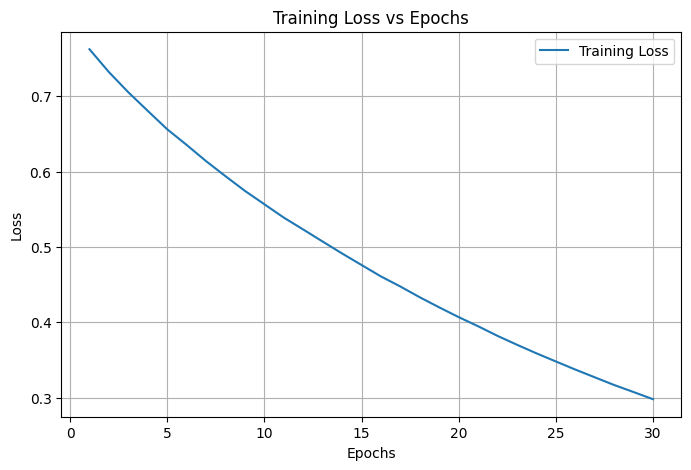

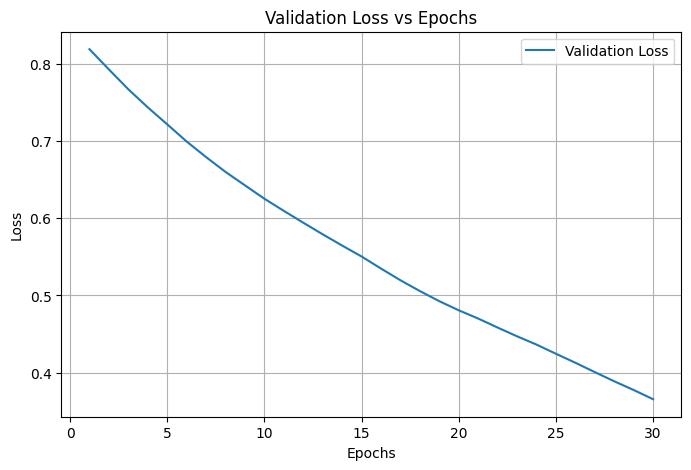

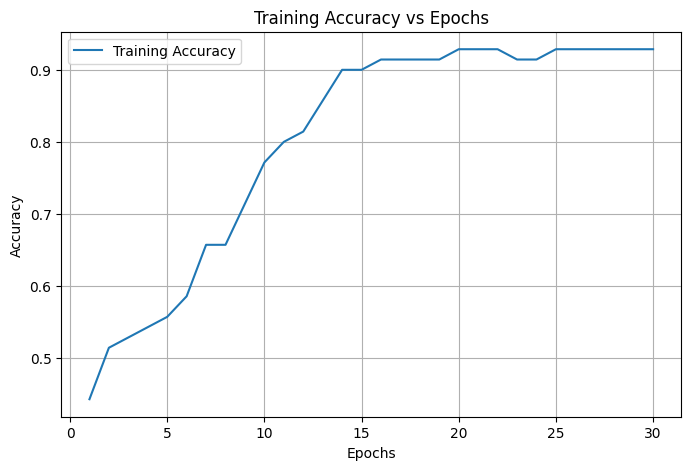

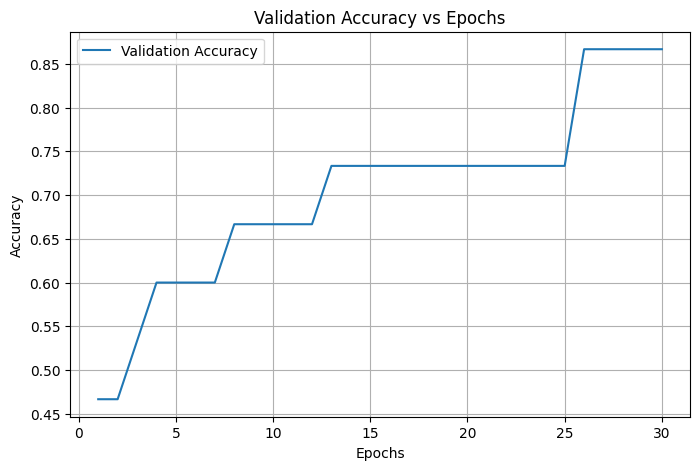

In [ ]:
import matplotlib.pyplot as plt

# Get training history
epochs = range(1, len(history.history["loss"]) + 1)

# 1. Training Loss vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()


# 2. Validation Loss vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()


# 3. Training Accuracy vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()


# 4. Validation Accuracy vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Generate predictions for test students

predicted_probabilities = model.predict(X_test)

# Convert probabilities into Pass/Fail
predicted_classes = (predicted_probabilities >= 0.5).astype(int)

print("Actual values:")
print(y_test.to_numpy())

print("\nPredicted values:")
print(predicted_classes.flatten())

print("\nPredicted probabilities:")
print(predicted_probabilities.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Actual values:
[0 1 1 0 1 1 1 1 1 0 0 1 1 1 1]

Predicted values:
[0 1 1 0 1 1 1 1 1 0 0 1 1 1 1]

Predicted probabilities:
[0.15632582 0.9219784  0.93714577 0.4326771  0.61632735 0.7371494
 0.85132307 0.7986492  0.5366145  0.3044404  0.3383746  0.9436471
 0.7398586  0.81757176 0.5052823 ]
